In [1]:
import pandas as pd
import os

# def process_corpus(csv_file, src_out, tgt_out):
#     # Load CSV
#     df = pd.read_csv(csv_file)

#     # Sanity check for required columns
#     if not {"src", "tgt"}.issubset(df.columns):
#         raise ValueError("CSV file must contain 'src' and 'tgt' columns")

#     # Remove duplicate pairs (src, tgt)
#     before = len(df)
#     df = df.drop_duplicates(subset=["src", "tgt"])
#     after = len(df)
#     print(f"Removed {before - after} duplicate records.")

#     # Ensure output directory exists
#     os.makedirs(os.path.dirname(src_out), exist_ok=True)

#     # Write to separate files
#     df["src"].to_csv(src_out, index=False, header=False)
#     df["tgt"].to_csv(tgt_out, index=False, header=False)

#     print(f"Written {after} records to '{src_out}' and '{tgt_out}'.")

# if __name__ == "__main__":
#     script_dir = os.path.dirname(os.path.abspath(__file__))
#     project_root = os.path.dirname(script_dir)

#     input_csv = os.path.join(script_dir, "annotated-preprocess", "translated_tweets.csv")
#     out_dir = os.path.join(project_root, "corpus-parallel-txt")
#     src_out = os.path.join(out_dir, "train.en.cleaned")
#     tgt_out = os.path.join(out_dir, "train.tl.cleaned")

#     process_corpus(input_csv, src_out, tgt_out)

In [2]:
df = pd.read_csv("annotated-preprocess/annotated_tweets.csv")

df.head()

,src,tgt
0,Parang may lamay sa grammy eh noh antamlay mag...,"It feels like a wake at the Grammys, doesn't i..."
1,User talaga kayo di ba kayo aangat pag wla boy...,"You guys are such users, wouldn't you amount t..."
2,Si la pobre de Evelyn y su pareja Wilson creo ...,"Poor Evelyn and her partner Wilson, I think th..."
3,O 'di ba kung kailan 'di na tayo nagkikita sa ...,Isn't it just when we no longer see each other...
4,Il cane di BA Io se fossi al suo posto BarisArduç,"If I were in BA Io's dog's place, I'd be Baris..."


In [3]:
# remove duplicate pairs
before = len(df)
df = df.drop_duplicates(subset=["src", "tgt"])
after = len(df)
print(f"Removed {before - after} duplicate records.")

Removed 2 duplicate records.


In [5]:
len(df)

3502

In [4]:
df.head()

,src,tgt
0,Parang may lamay sa grammy eh noh antamlay mag...,"It feels like a wake at the Grammys, doesn't i..."
1,User talaga kayo di ba kayo aangat pag wla boy...,"You guys are such users, wouldn't you amount t..."
2,Si la pobre de Evelyn y su pareja Wilson creo ...,"Poor Evelyn and her partner Wilson, I think th..."
3,O 'di ba kung kailan 'di na tayo nagkikita sa ...,Isn't it just when we no longer see each other...
4,Il cane di BA Io se fossi al suo posto BarisArduç,"If I were in BA Io's dog's place, I'd be Baris..."


In [6]:
# check for null or empty strings
null_src = df['src'].isnull().sum()
null_tgt = df['tgt'].isnull().sum()

empty_src = (df['src'].str.strip() == '').sum()
empty_tgt = (df['tgt'].str.strip() == '').sum()
print(f"Null src: {null_src}, Null tgt: {null_tgt}")
print(f"Empty src: {empty_src}, Empty tgt: {empty_tgt}")

# remove rows with null or empty strings
df = df.dropna(subset=['src', 'tgt'])
df = df[(df['src'].str.strip() != '') & (df['tgt'].str.strip() != '')]
after_cleaning = len(df)

print(f"Removed {after - after_cleaning} records with null or empty strings.")

Null src: 0, Null tgt: 0
Empty src: 0, Empty tgt: 0
Removed 0 records with null or empty strings.


In [7]:
df.shape

(3502, 2)

In [8]:
# save cleaned dataframe
# df.to_csv("annotated-preprocess/translated_tweets_cleaned.csv", index=False)

In [10]:
# output `src` and `tgt` to separate text files: train.tl.cleaned, train.en.cleaned, val.tl.cleaned, val.en.cleaned 80-20 split
src_out = "../corpus-parallel-txt/train.tl.cleaned"
tgt_out = "../corpus-parallel-txt/train.en.cleaned"
val_src_out = "../corpus-parallel-txt/val.tl.cleaned"
val_tgt_out = "../corpus-parallel-txt/val.en.cleaned"
train_size = int(0.8 * len(df))
df.iloc[:train_size]["src"].to_csv(src_out, index=False, header=False)
df.iloc[:train_size]["tgt"].to_csv(tgt_out, index=False, header=False)
df.iloc[train_size:]["src"].to_csv(val_src_out, index=False, header=False)
df.iloc[train_size:]["tgt"].to_csv(val_tgt_out, index=False, header=False)

print(f"Written {train_size} training records to '{src_out}' and '{tgt_out}'.")

Written 2801 training records to '../corpus-parallel-txt/train.tl.cleaned' and '../corpus-parallel-txt/train.en.cleaned'.


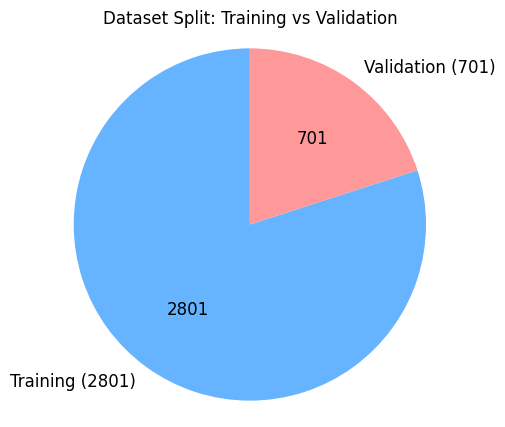

In [12]:
import matplotlib.pyplot as plt

# Pie chart of dataset split (show actual counts, not percentages)
sizes = [train_size, len(df) - train_size]
labels = [f'Training ({train_size})', f'Validation ({len(df) - train_size})']
colors = ['#66b3ff', '#ff9999']

plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, autopct=lambda pct: f"{int(round(pct/100.*sum(sizes)))}", startangle=90, colors=colors, textprops={'fontsize': 12})
plt.title('Dataset Split: Training vs Validation')
plt.axis('equal')
plt.show()
